In [ ]:
!pip install -q transformers peft accelerate bitsandbytes scikit-learn wandb matplotlib
print("dependencies installed")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 39.6 MB/s eta 0:00:00
dependencies installed


In [ ]:
import os
# ============ FILL THESE IN ============
WANDB_API_KEY = os.environ.get("WANDB_API_KEY", "")  # set in your environment (see .env.example)
HF_TOKEN      = os.environ.get("HF_TOKEN", "")  # set in your environment (see .env.example)
# =======================================

import wandb
from huggingface_hub import login

if WANDB_API_KEY:
    wandb.login(key=WANDB_API_KEY)
    print("W&B: logged in")
else:
    print("set WANDB_API_KEY")

if HF_TOKEN:
    login(token=HF_TOKEN)
    print("Hugging Face: logged in")
else:
    print("set HF_TOKEN (required for the gated Llama-3.2 model)")

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: raghav9raghav (raghav9raghav-hochschule-luzern) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


W&B: logged in
Hugging Face: logged in


In [ ]:
import time, random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from sklearn.datasets import fetch_20newsgroups
from sklearn.metrics import accuracy_score, f1_score

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

device: cuda


In [ ]:
remove = ("headers", "footers", "quotes")
train_raw = fetch_20newsgroups(subset="train", remove=remove, random_state=SEED)
test_raw  = fetch_20newsgroups(subset="test",  remove=remove, random_state=SEED)
label_names = list(train_raw.target_names)
NUM_CLASSES = len(label_names)

X_train, y_train = list(train_raw.data), train_raw.target.tolist()
X_test,  y_test  = list(test_raw.data),  test_raw.target.tolist()

# Training subset: up to 100 docs per class
MAX_PER_CLASS = 100
texts, labels, counts = [], [], {}
for t, y in zip(X_train, y_train):
    counts.setdefault(y, 0)
    if counts[y] < MAX_PER_CLASS:
        texts.append(t); labels.append(y); counts[y] += 1
print(f"training docs: {len(texts)}")

# Balanced eval set: 5 docs/class = 100 docs (the SAME set for all three methods -> fair comparison)
by_cls = {}
for t, y in zip(X_test, y_test):
    by_cls.setdefault(y, []).append(t)
rng = random.Random(SEED)
eval_texts, eval_labels = [], []
for y in sorted(by_cls):
    picks = rng.sample(by_cls[y], min(5, len(by_cls[y])))
    eval_texts += picks; eval_labels += [y] * len(picks)
print(f"eval docs: {len(eval_texts)}")

# Few-shot demonstrations: 1 example per class from the training subset
demo_by_cls = {}
for t, y in zip(texts, labels):
    demo_by_cls.setdefault(y, t)
few_shot_examples = [(demo_by_cls[y], label_names[y]) for y in sorted(demo_by_cls)]
print(f"few-shot demonstrations: {len(few_shot_examples)}")

training docs: 2000
eval docs: 100
few-shot demonstrations: 20


In [ ]:
def make_prompt(text, label=None, max_chars=1500):
    p = ("Classify the following news article into exactly one of these categories:\n"
         + ", ".join(label_names) + "\n\n"
         + f"Article:\n{text[:max_chars]}\n\nCategory:")
    if label is not None:
        p += " " + label
    return p

def make_few_shot_prompt(text, examples, max_chars=1500, demo_chars=400):
    parts = ["Classify news articles into exactly one of these categories:\n"
             + ", ".join(label_names) + "\n\nExamples:"]
    for ex_text, ex_label in examples:
        parts.append(f"\nArticle:\n{ex_text[:demo_chars]}\n\nCategory: {ex_label}")
    parts.append(f"\n\nNow classify this article:\nArticle:\n{text[:max_chars]}\n\nCategory:")
    return "".join(parts)

def parse_label(generated):
    g = generated.lower()
    for name in label_names:
        if name.lower() in g:
            return name
    return "unknown"

In [ ]:
MODEL_NAME = "unsloth/Llama-3.2-3B-Instruct"
# No access to the gated model? Comment the line above and uncomment this ungated one:
# MODEL_NAME = "NousResearch/Meta-Llama-3.1-8B-Instruct"
MAX_LENGTH = 256

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token

bnb = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_quant_type="nf4",
                         bnb_4bit_compute_dtype=torch.float16,
                         bnb_4bit_use_double_quant=True)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME, quantization_config=bnb, device_map="auto")
model.config.use_cache = True
model.eval()
print("model loaded")

config.json:   0%|          | 0.00/890 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/454 [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/234 [00:00<?, ?B/s]

model loaded


In [ ]:
@torch.no_grad()
def generate_label(prompt, max_new_tokens=10):
    inp = tokenizer(prompt, return_tensors="pt", truncation=True,
                    max_length=2048).to(model.device)
    out = model.generate(**inp, max_new_tokens=max_new_tokens, do_sample=False,
                         pad_token_id=tokenizer.eos_token_id)
    return tokenizer.decode(out[0, inp["input_ids"].shape[1]:],
                            skip_special_tokens=True).strip()

In [ ]:
run = wandb.init(project="nalapro-bonus", name="llama3-qlora-bonus", reinit=True,
                 config={"model": MODEL_NAME, "max_per_class": MAX_PER_CLASS,
                         "eval_size": len(eval_texts), "max_len": MAX_LENGTH})

wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


In [ ]:
true_zs, pred_zs = [], []
t0 = time.time()
for text, y in zip(eval_texts, eval_labels):
    pred = parse_label(generate_label(make_prompt(text)))
    true_zs.append(label_names[y]); pred_zs.append(pred)
zs_runtime = time.time() - t0
acc_zs = accuracy_score(true_zs, pred_zs)
f1_zs  = f1_score(true_zs, pred_zs, average="macro", labels=label_names, zero_division=0)
wandb.log({"zeroshot_runtime_s": zs_runtime, "zeroshot_accuracy": acc_zs, "zeroshot_f1": f1_zs})
print(f"zero-shot:  acc={acc_zs:.4f}  f1={f1_zs:.4f}  ({zs_runtime:.0f}s)")

The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


zero-shot:  acc=0.1700  f1=0.1646  (80s)


In [ ]:
true_fs, pred_fs = [], []
t0 = time.time()
for text, y in zip(eval_texts, eval_labels):
    pred = parse_label(generate_label(make_few_shot_prompt(text, few_shot_examples)))
    true_fs.append(label_names[y]); pred_fs.append(pred)
fs_runtime = time.time() - t0
acc_fs = accuracy_score(true_fs, pred_fs)
f1_fs  = f1_score(true_fs, pred_fs, average="macro", labels=label_names, zero_division=0)
wandb.log({"fewshot_runtime_s": fs_runtime, "fewshot_accuracy": acc_fs, "fewshot_f1": f1_fs})
print(f"few-shot:  acc={acc_fs:.4f}  f1={f1_fs:.4f}  ({fs_runtime:.0f}s)")

few-shot:  acc=0.0000  f1=0.0000  (102s)


In [ ]:
# Attach LoRA adapters
model = prepare_model_for_kbit_training(model)
model = get_peft_model(model, LoraConfig(
    r=8, lora_alpha=16, lora_dropout=0.05, bias="none", task_type="CAUSAL_LM",
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"]))
model.print_trainable_parameters()

# Build training tensors (prompt + answer); mask padding from the loss
train_prompts = [make_prompt(t, label_names[y]) for t, y in zip(texts, labels)]
enc = tokenizer(train_prompts, truncation=True, padding="max_length",
                max_length=MAX_LENGTH, return_tensors="pt")
input_ids, attn = enc["input_ids"], enc["attention_mask"]
lm_labels = input_ids.clone(); lm_labels[attn == 0] = -100

class PromptDS(Dataset):
    def __len__(self): return input_ids.size(0)
    def __getitem__(self, i):
        return {"input_ids": input_ids[i], "attention_mask": attn[i], "labels": lm_labels[i]}

loader = DataLoader(PromptDS(), batch_size=2, shuffle=True)
ACCUM, EPOCHS, LR = 4, 1, 2e-4                      # effective batch 8
opt = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=LR)
scaler = torch.cuda.amp.GradScaler()

model.config.use_cache = False
model.train()
t0, step = time.time(), 0
for ep in range(EPOCHS):
    opt.zero_grad()
    for i, b in enumerate(loader):
        b = {k: v.to(model.device) for k, v in b.items()}
        with torch.cuda.amp.autocast():
            loss = model(**b).loss / ACCUM
        scaler.scale(loss).backward()
        if (i + 1) % ACCUM == 0:
            scaler.step(opt); scaler.update(); opt.zero_grad(); step += 1
            if step % 10 == 0:
                cur = loss.item() * ACCUM
                wandb.log({"train_loss": cur, "step": step})
                print(f"  step {step}  loss {cur:.4f}  elapsed {time.time()-t0:.0f}s")
train_runtime = time.time() - t0
wandb.log({"train_runtime_s": train_runtime, "train_runtime_min": train_runtime/60})
print(f"training runtime: {train_runtime/60:.2f} min")

model.save_pretrained("llama3_lora_classifier")
tokenizer.save_pretrained("llama3_lora_classifier")

trainable params: 4,587,520 || all params: 3,217,337,344 || trainable%: 0.1426


/tmp/ipykernel_784/1386661968.py:23: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/tmp/ipykernel_784/1386661968.py:32: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


  step 10  loss 1.7858  elapsed 23s
  step 20  loss 1.5769  elapsed 45s
  step 30  loss 1.6913  elapsed 67s
  step 40  loss 1.9610  elapsed 89s
  step 50  loss 1.5873  elapsed 112s
  step 60  loss 1.8371  elapsed 134s
  step 70  loss 1.3859  elapsed 156s
  step 80  loss 1.5201  elapsed 178s
  step 90  loss 1.3140  elapsed 201s
  step 100  loss 1.2667  elapsed 223s
  step 110  loss 1.5680  elapsed 245s
  step 120  loss 1.7556  elapsed 267s
  step 130  loss 1.6886  elapsed 289s
  step 140  loss 1.4141  elapsed 312s
  step 150  loss 1.7504  elapsed 334s
  step 160  loss 2.2520  elapsed 356s
  step 170  loss 1.3981  elapsed 378s
  step 180  loss 1.6090  elapsed 400s
  step 190  loss 1.8462  elapsed 423s
  step 200  loss 1.1080  elapsed 445s
  step 210  loss 1.7927  elapsed 467s
  step 220  loss 1.3519  elapsed 489s
  step 230  loss 1.3920  elapsed 511s
  step 240  loss 1.3362  elapsed 534s
  step 250  loss 1.6939  elapsed 556s
training runtime: 9.27 min


('llama3_lora_classifier/tokenizer_config.json',
 'llama3_lora_classifier/chat_template.jinja',
 'llama3_lora_classifier/tokenizer.json')

In [ ]:
model.config.use_cache = True
model.eval()
true_lora, pred_lora = [], []
t0 = time.time()
for text, y in zip(eval_texts, eval_labels):
    pred = parse_label(generate_label(make_prompt(text)))
    true_lora.append(label_names[y]); pred_lora.append(pred)
lora_runtime = time.time() - t0
acc_lora = accuracy_score(true_lora, pred_lora)
f1_lora  = f1_score(true_lora, pred_lora, average="macro", labels=label_names, zero_division=0)
wandb.log({"lora_eval_runtime_s": lora_runtime, "lora_accuracy": acc_lora, "lora_f1": f1_lora})
print(f"LoRA fine-tuned:  acc={acc_lora:.4f}  f1={f1_lora:.4f}  ({lora_runtime:.0f}s)")

LoRA fine-tuned:  acc=0.5300  f1=0.5018  (111s)


           Model  Accuracy  Macro F1  Eval runtime (s)
       Zero-shot      0.17  0.164592         80.247899
        Few-shot      0.00  0.000000        102.486568
QLoRA fine-tuned      0.53  0.501788        110.932665


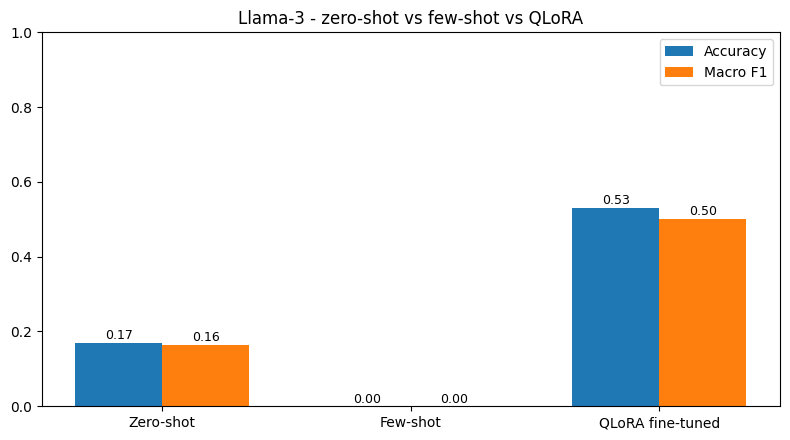

fewshot_accuracy,▁
fewshot_f1,▁
fewshot_runtime_s,▁
lora_accuracy,▁
lora_eval_runtime_s,▁
lora_f1,▁
step,▁▁▂▂▂▂▃▃▃▄▄▄▅▅▅▅▆▆▆▇▇▇▇██
train_loss,▅▄▅▆▄▅▃▄▂▂▄▅▅▃▅█▃▄▆▁▅▂▃▂▅
train_runtime_min,▁
train_runtime_s,▁
+3,...


,Model,Accuracy,Macro F1,Eval runtime (s)
0,Zero-shot,0.17,0.164592,80.247899
1,Few-shot,0.00,0.000000,102.486568
2,QLoRA fine-tuned,0.53,0.501788,110.932665


In [ ]:
comparison = pd.DataFrame({
    "Model":            ["Zero-shot", "Few-shot", "QLoRA fine-tuned"],
    "Accuracy":         [acc_zs, acc_fs, acc_lora],
    "Macro F1":         [f1_zs, f1_fs, f1_lora],
    "Eval runtime (s)": [zs_runtime, fs_runtime, lora_runtime],
})
print(comparison.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(3); w = 0.35
ax.bar(x - w/2, comparison["Accuracy"], w, label="Accuracy")
ax.bar(x + w/2, comparison["Macro F1"], w, label="Macro F1")
ax.set_xticks(x); ax.set_xticklabels(comparison["Model"])
ax.set_ylim(0, 1); ax.legend()
ax.set_title("Llama-3 - zero-shot vs few-shot vs QLoRA")
for i, v in enumerate(comparison["Accuracy"]): ax.text(i - w/2, v + .01, f"{v:.2f}", ha="center", fontsize=9)
for i, v in enumerate(comparison["Macro F1"]):  ax.text(i + w/2, v + .01, f"{v:.2f}", ha="center", fontsize=9)
plt.tight_layout(); plt.savefig("bonus_comparison.png", dpi=120); plt.show()

wt = wandb.Table(columns=["Model", "Accuracy", "Macro F1", "Eval runtime (s)"],
                 data=comparison.values.tolist())
wandb.log({"comparison_table": wt})
wandb.finish()
comparison